環境設置：安裝必要套件並檢查CUDA可用性

資料集下載：從HuggingFace下載漫畫資料集並分割訓練/驗證集

資料管道：建立Dataset和DataLoader，包含數據增強

模型架構：實現U-Net生成器和PatchGAN判別器

訓練準備：定義損失函數、優化器和評估指標

模型訓練：完整訓練循環，包含AMP混合精度訓練

結果可視化：繪製訓練曲線和指標變化

互動介面：使用Gradio創建用戶友好的測試界面

In [ ]:
# 階段 1：環境設置與套件安裝
# 安裝所有必要套件並檢查硬體環境

!pip install torch torchvision torchmetrics matplotlib scikit-image pillow tqdm gradio gitpython --upgrade -q
!git lfs install

import torch
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
print(f"GPU型號: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '無'}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
# 階段 2：資料集下載與預處理
# 從HuggingFace下載漫畫上色資料集並進行預處理

import os
import pandas as pd
from PIL import Image
import io
from tqdm import tqdm
import random

# 下載資料集
if not os.path.exists("manga-colorization-dataset"):
    !git clone https://huggingface.co/datasets/MichaelP84/manga-colorization-dataset
    %cd manga-colorization-dataset
    !git lfs pull
    %cd ..

# 創建保存目錄
os.makedirs("train/bw", exist_ok=True)
os.makedirs("train/color", exist_ok=True)
os.makedirs("val/bw", exist_ok=True)
os.makedirs("val/color", exist_ok=True)

# 設定訓練和驗證集比例
train_ratio = 0.9
total_count = 0
train_count = 0
val_count = 0

# 處理並保存圖像
for file in tqdm(sorted(os.listdir("manga-colorization-dataset/data"))[:10]):
    if file.endswith(".parquet"):
        df = pd.read_parquet(f"manga-colorization-dataset/data/{file}")
        for _, row in df.iterrows():
            try:
                is_train = random.random() < train_ratio
                if is_train and train_count < 4500:
                    bw_path = f"train/bw/{train_count:05}.png"
                    color_path = f"train/color/{train_count:05}.png"
                    train_count += 1
                elif val_count < 500:
                    bw_path = f"val/bw/{val_count:05}.png"
                    color_path = f"val/color/{val_count:05}.png"
                    val_count += 1
                else:
                    continue

                Image.open(io.BytesIO(row["bw_image"]["bytes"])).resize((256,256)).save(bw_path)
                Image.open(io.BytesIO(row["color_image"]["bytes"])).resize((256,256)).save(color_path)

                total_count += 1
                if total_count >= 5000:
                    break
            except:
                continue
        if total_count >= 5000:
            break

print(f"✅ 資料集準備完成 - 訓練集: {train_count}張, 驗證集: {val_count}張")


Cloning into 'manga-colorization-dataset'...
remote: Enumerating objects: 50, done.
remote: Total 50 (delta 0), reused 0 (delta 0), pack-reused 50 (from 1)
Unpacking objects: 100% (50/50), 8.53 KiB | 1.07 MiB/s, done.
You can inspect what was checked out with 'git status'
and retry with 'git restore --source=HEAD :/'


Exiting because of "interrupt" signal.
^C
/content/manga-colorization-dataset
Error updating the git index:
error: data/train-00040-of-00043.parquet: cannot add to the index - missing --add option?
fatal: Unable to process path data/train-00040-of-00043.parquet


Errors logged to /content/manga-colorization-dataset/.git/lfs/logs/20250603T074901.98847224.log
Use `git lfs logs last` to view the log.
/content


100%|██████████| 10/10 [03:26<00:00, 20.70s/it]

✅ 資料集準備完成 - 訓練集: 2494張, 驗證集: 285張


In [ ]:
# 階段 3：建立資料管道
# 創建Dataset和DataLoader用於訓練

# %%
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class MangaDataset(Dataset):
    def __init__(self, bw_dir, color_dir, augment=True):
        self.bw_images = sorted(os.listdir(bw_dir))
        self.color_images = sorted(os.listdir(color_dir))
        self.bw_dir = bw_dir
        self.color_dir = color_dir
        self.augment = augment
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)) if bw_dir.endswith("bw") else
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
        ])

    def __len__(self):
        return len(self.bw_images)

    def __getitem__(self, idx):
      try:
          bw_img = Image.open(os.path.join(self.bw_dir, self.bw_images[idx])).convert("L")
          color_img = Image.open(os.path.join(self.color_dir, self.color_images[idx])).convert("RGB")

          if self.augment:
              if random.random() > 0.5:
                  bw_img = transforms.functional.hflip(bw_img)
                  color_img = transforms.functional.hflip(color_img)
              if random.random() > 0.5:
                  bw_img = transforms.functional.vflip(bw_img)
                  color_img = transforms.functional.vflip(color_img)

          bw_tensor = transforms.ToTensor()(bw_img)
          color_tensor = transforms.ToTensor()(color_img)

          bw_tensor = transforms.Normalize((0.5,), (0.5,))(bw_tensor)
          color_tensor = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))(color_tensor)

          return bw_tensor, color_tensor
      except Exception as e:
          print(f"❌ 圖片讀取失敗（index {idx}）: {e}")
          return self.__getitem__((idx + 1) % len(self))  # 避免因為錯誤整批崩潰

# %%
# 創建資料集和載入器
train_ds = MangaDataset("train/bw", "train/color")
val_ds = MangaDataset("val/bw", "val/color", augment=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

sample_bw, sample_color = next(iter(train_loader))
print(f"批次形狀 - 黑白圖: {sample_bw.shape}, 彩色圖: {sample_color.shape}")


批次形狀 - 黑白圖: torch.Size([16, 1, 256, 256]), 彩色圖: torch.Size([16, 3, 256, 256])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = self.down_block(1, 64, normalize=False)
        self.down2 = self.down_block(64, 128)
        self.down3 = self.down_block(128, 256)
        self.down4 = self.down_block(256, 512, dropout=0.5)
        self.down5 = self.down_block(512, 512, dropout=0.5)

        self.up1 = self.up_block(512, 512, dropout=0.5)
        self.up2 = self.up_block(1024, 256)
        self.up3 = self.up_block(512, 128)
        self.up4 = self.up_block(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def down_block(self, in_c, out_c, normalize=True, dropout=0.0):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def up_block(self, in_c, out_c, dropout=0.0):
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        d1 = self.down1(x)  # 128x128
        d2 = self.down2(d1) # 64x64
        d3 = self.down3(d2) # 32x32
        d4 = self.down4(d3) # 16x16
        d5 = self.down5(d4) # 8x8

        u1 = self.up1(d5)  # 16x16
        u2 = self.up2(torch.cat([u1, d4], 1))  # 32x32
        u3 = self.up3(torch.cat([u2, d3], 1))  # 64x64
        u4 = self.up4(torch.cat([u3, d2], 1))  # 128x128

        out = self.final(torch.cat([u4, d1], 1))  # ✅ 256x256

        return out


In [ ]:
class PatchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, 2, 1)]
            if normalization:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2))
            return layers
        self.model = nn.Sequential(
            *block(4, 64, normalization=False),
            *block(64, 128),
            *block(128, 256),
            *block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )

    def forward(self, img_A, img_B):
        return self.model(torch.cat((img_A, img_B), 1))


In [ ]:
# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)

print(f"生成器參數量: {sum(p.numel() for p in G.parameters())}")
print(f"判別器參數量: {sum(p.numel() for p in D.parameters())}")


生成器參數量: 16658051
判別器參數量: 2765761


In [ ]:
# 階段 5：訓練準備

from torch.optim import Adam
from torch.cuda.amp import GradScaler, autocast
from torchvision.models import vgg16
from torchvision.utils import save_image
import matplotlib.pyplot as plt

lr = 2e-4
beta1, beta2 = 0.5, 0.999
opt_G = Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
opt_D = Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

criterion_GAN = nn.MSELoss()
criterion_L1 = nn.L1Loss()

vgg = vgg16(pretrained=True).features[:16].to(device).eval()
for param in vgg.parameters():
    param.requires_grad = False

def perceptual_loss(fake, real):
    return criterion_L1(vgg(fake), vgg(real))

scaler = GradScaler()
os.makedirs("samples", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)


<ipython-input-87-f5d7dc568596>:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


✅ 第一個：基本 GAN + Perceptual Loss 版
模型：Pix2Pix (UNet + PatchGAN)

損失：GAN Loss + L1 Loss + Perceptual Loss（perceptual_loss）

風格損失：❌ 無 Style Loss

Warm-up 訓練：❌ 沒有

驗證 Loss：使用 L1 驗證 Loss 儲存最佳模型

保存模型頻率：每隔幾個 epoch 或最後一輪

📌 用途：入門版本 + 加入感知損失，提升細節感知。

In [ ]:
# 階段 6：訓練循環（含最佳模型儲存與 Loss 繪圖）

best_val_loss = float('inf')
gen_losses, disc_losses, val_l1_losses = [], [], []

for epoch in range(1, epochs + 1):
    G.train()
    D.train()
    total_g_loss = 0
    total_d_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
    for bw_imgs, color_imgs in loop:
        bw_imgs = bw_imgs.to(device)
        color_imgs = color_imgs.to(device)

        # === 訓練判別器 ===
        with autocast():
            fake_color = G(bw_imgs)
            D_real = D(bw_imgs, color_imgs)
            D_fake = D(bw_imgs, fake_color.detach())

            loss_real = criterion_GAN(D_real, torch.ones_like(D_real))
            loss_fake = criterion_GAN(D_fake, torch.zeros_like(D_fake))
            d_loss = (loss_real + loss_fake) * 0.5

        opt_D.zero_grad()
        scaler.scale(d_loss).backward()
        scaler.step(opt_D)

        # === 訓練生成器 ===
        with autocast():
            D_fake = D(bw_imgs, fake_color)
            gan_loss = criterion_GAN(D_fake, torch.ones_like(D_fake))
            l1_loss = criterion_L1(fake_color, color_imgs)
            p_loss = perceptual_loss(fake_color, color_imgs)
            g_loss = gan_loss + lambda_L1 * l1_loss + lambda_perceptual * p_loss

        opt_G.zero_grad()
        scaler.scale(g_loss).backward()
        scaler.step(opt_G)
        scaler.update()

        total_g_loss += g_loss.item()
        total_d_loss += d_loss.item()
        loop.set_postfix(G_Loss=total_g_loss / (loop.n + 1), D_Loss=total_d_loss / (loop.n + 1))

    gen_losses.append(total_g_loss / len(train_loader))
    disc_losses.append(total_d_loss / len(train_loader))

    # === 驗證階段 ===
    G.eval()
    val_loss = 0
    with torch.no_grad():
        for bw_imgs, color_imgs in val_loader:
            bw_imgs = bw_imgs.to(device)
            color_imgs = color_imgs.to(device)
            fake_color = G(bw_imgs)
            val_loss += criterion_L1(fake_color, color_imgs).item()
    val_l1 = val_loss / len(val_loader)
    val_l1_losses.append(val_l1)
    print(f"🔍 驗證 L1 Loss: {val_l1:.4f}")

    # === 儲存最佳模型 ===
    if val_l1 < best_val_loss:
        best_val_loss = val_l1
        torch.save(G.state_dict(), "checkpoints/best_model.pth")
        print(f"✅ 已儲存最佳模型（epoch {epoch}, L1={val_l1:.4f}）")

    # === 儲存範例圖片與模型 ===
    if epoch % save_interval == 0 or epoch == epochs:
        val_bw, val_color = next(iter(val_loader))
        val_bw = val_bw.to(device)
        with torch.no_grad():
            fake_val = G(val_bw)
        save_image((val_bw[:4] + 1) / 2, f"samples/epoch{epoch}_bw.png", nrow=4)
        save_image((fake_val[:4] + 1) / 2, f"samples/epoch{epoch}_fake.png", nrow=4)
        save_image((val_color[:4] + 1) / 2, f"samples/epoch{epoch}_real.png", nrow=4)

        torch.save(G.state_dict(), f"checkpoints/unet_pix2pix_epoch{epoch}.pth")


Epoch 1/200:   0%|          | 0/156 [00:00<?, ?it/s]<ipython-input-31-c8632efa7e77>:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
<ipython-input-31-c8632efa7e77>:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/200: 100%|██████████| 156/156 [00:37<00:00,  4.18it/s, D_Loss=0.233, G_Loss=29.2]


🔍 驗證 L1 Loss: 0.1190
✅ 已儲存最佳模型（epoch 1, L1=0.1190）


Epoch 2/200: 100%|██████████| 156/156 [00:36<00:00,  4.26it/s, D_Loss=0.107, G_Loss=18]


🔍 驗證 L1 Loss: 0.1044
✅ 已儲存最佳模型（epoch 2, L1=0.1044）


Epoch 3/200: 100%|██████████| 156/156 [00:36<00:00,  4.32it/s, D_Loss=0.0689, G_Loss=16.4]


...

🔍 驗證 L1 Loss: 0.0683


Epoch 199/200: 100%|██████████| 156/156 [00:36<00:00,  4.30it/s, D_Loss=0.0416, G_Loss=9.11]


🔍 驗證 L1 Loss: 0.0677


Epoch 200/200: 100%|██████████| 156/156 [00:36<00:00,  4.28it/s, D_Loss=0.0605, G_Loss=9.1]


🔍 驗證 L1 Loss: 0.0681


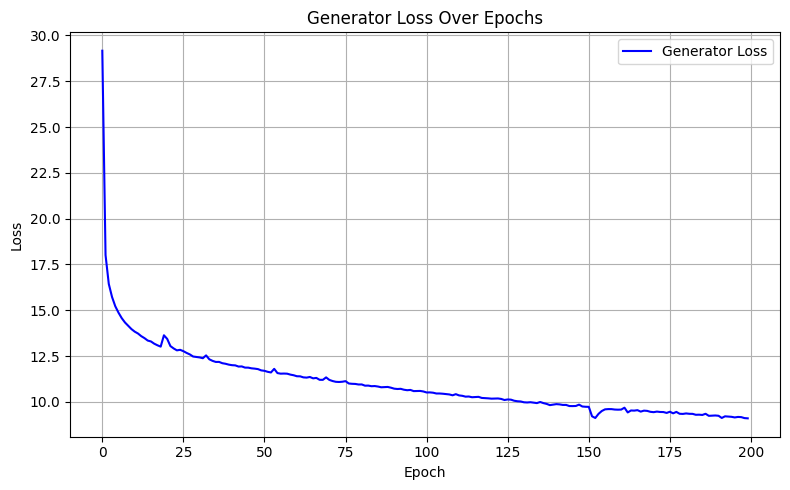

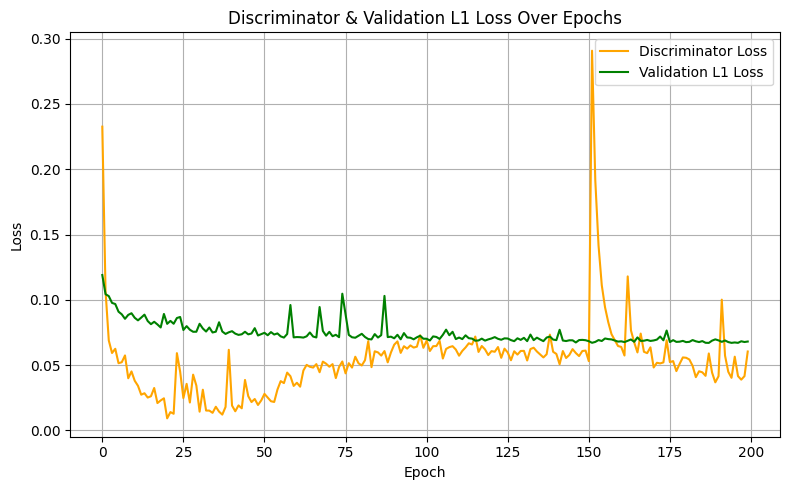

In [ ]:
# 階段 7：Loss 曲線繪圖

import matplotlib.pyplot as plt

# 圖一：Generator Loss
plt.figure(figsize=(8, 5))
plt.plot(gen_losses, color='blue', label='Generator Loss')
plt.title("Generator Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 圖二：Discriminator Loss + Validation L1 Loss
plt.figure(figsize=(8, 5))
plt.plot(disc_losses, color='orange', label='Discriminator Loss')
plt.plot(val_l1_losses, color='green', label='Validation L1 Loss')
plt.title("Discriminator & Validation L1 Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
!pip install scikit-image
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.3/323.3 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 138.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 6.3 MB/s eta 0:00:00


In [ ]:
import gradio as gr
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import os

# ✅ 載入模型結構（需與訓練時相符）
import torch.nn as nn

class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = self.down_block(1, 64, normalize=False)
        self.down2 = self.down_block(64, 128)
        self.down3 = self.down_block(128, 256)
        self.down4 = self.down_block(256, 512, dropout=0.5)
        self.down5 = self.down_block(512, 512, dropout=0.5)
        self.up1 = self.up_block(512, 512, dropout=0.5)
        self.up2 = self.up_block(1024, 256)
        self.up3 = self.up_block(512, 128)
        self.up4 = self.up_block(256, 64)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def down_block(self, in_c, out_c, normalize=True, dropout=0.0):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def up_block(self, in_c, out_c, dropout=0.0):
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        u1 = self.up1(d5)
        u2 = self.up2(torch.cat([u1, d4], 1))
        u3 = self.up3(torch.cat([u2, d3], 1))
        u4 = self.up4(torch.cat([u3, d2], 1))
        return self.final(torch.cat([u4, d1], 1))

# ✅ 載入訓練好的權重
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = UNetGenerator().to(device)
G.load_state_dict(torch.load("checkpoints/unet_pix2pix_epoch195.pth", map_location=device))
G.eval()

# ✅ 圖像處理函式
def preprocess_image(img):
    bw = img.convert("L").resize((256, 256))
    bw_tensor = transforms.ToTensor()(bw)
    bw_tensor = transforms.Normalize((0.5,), (0.5,))(bw_tensor)
    return bw_tensor.unsqueeze(0).to(device), np.array(bw)

def postprocess_image(tensor):
    img = tensor.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip((img + 1) / 2, 0, 1)

# ✅ 預測與評估
def colorize_and_evaluate(input_img):
    bw_tensor, bw_array = preprocess_image(input_img)
    with torch.no_grad():
        pred = G(bw_tensor)[0]
    pred_img = postprocess_image(pred)

    # ground truth 為彩圖（用來計算 SSIM / PSNR）
    try:
        gt = input_img.convert("RGB").resize((256, 256))
        gt_tensor = transforms.ToTensor()(gt)
        gt_tensor = transforms.Normalize((0.5,), (0.5,))(gt_tensor)
        gt_np = postprocess_image(gt_tensor)
        ssim_score = ssim(gt_np, pred_img, channel_axis=-1, data_range=1.0)
        psnr_score = psnr(gt_np, pred_img, data_range=1.0)
        score_text = f"SSIM: {ssim_score:.4f}, PSNR: {psnr_score:.2f} dB"
    except:
        score_text = "⚠️ 無法計算 SSIM / PSNR（無彩圖 ground truth）"

    # 轉為可顯示圖像
    bw_disp = np.stack([bw_array]*3, axis=-1) / 255.0
    bw_image = Image.fromarray((bw_disp * 255).astype(np.uint8))
    pred_image = Image.fromarray((pred_img * 255).astype(np.uint8))
    bw_image.save("bw_result.png")
    pred_image.save("color_result.png")

    return [bw_disp, pred_img], score_text, "bw_result.png", "color_result.png"

# ✅ Gradio UI
iface = gr.Interface(
    fn=colorize_and_evaluate,
    inputs=gr.Image(type="pil", label="上傳黑白漫畫圖像"),
    outputs=[
        gr.Gallery(label="上色對比圖", columns=2, show_label=False),
        gr.Textbox(label="品質評估 (SSIM / PSNR)"),
        gr.File(label="下載黑白圖像"),
        gr.File(label="下載彩色圖像")
    ],
    title="📚 漫畫自動上色器",
    description="上傳黑白漫畫圖像，自動上色並評估品質，可下載結果圖像。"
)

if __name__ == "__main__":
    iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2136cdb0b8021619af.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ 第二個：完整 Pix2Pix + Perceptual + Style Loss 版
模型：Pix2Pix

損失：GAN + L1 + Perceptual + Style Loss（完整四項）

感知模型：使用 VGG16

Warm-up 訓練：❌ 沒有

保存策略：每隔數輪儲存 & 儲存最佳

目標：進一步提升風格一致性與內容保真

📌 用途：適合做高品質生成訓練，有完整風格與感知學習能力。

In [ ]:
# 階段 8：定義 Perceptual Loss 與 Style Loss

from torchvision.models import vgg16
import torch.nn.functional as F

# ✅ 載入 VGG16 特徵模型
from torchvision.models import vgg16, VGG16_Weights
vgg = vgg16(weights=VGG16_Weights.DEFAULT).features.to(device).eval()
for param in vgg.parameters():
    param.requires_grad = False

# ✅ 取得指定層輸出（感知層）
class VGGFeatures(nn.Module):
    def __init__(self, layer_ids=[3, 8, 15]):
        super().__init__()
        self.slices = nn.ModuleList()
        prev = 0
        for l in layer_ids:
            self.slices.append(nn.Sequential(*[vgg[i] for i in range(prev, l)]))
            prev = l
    def forward(self, x):
        feats = []
        for block in self.slices:
            x = block(x)
            feats.append(x)
        return feats

vgg_feat = VGGFeatures().to(device)

# ✅ Perceptual Loss（感知差異）
def perceptual_loss(fake, real):
    f_fake, f_real = vgg_feat(fake), vgg_feat(real)
    return sum(F.l1_loss(a, b) for a, b in zip(f_fake, f_real))

# ✅ Style Loss（風格一致性）
def gram_matrix(feature):
    b, c, h, w = feature.size()
    f = feature.view(b, c, -1)
    G = torch.bmm(f, f.transpose(1, 2))
    return G / (c * h * w)

def style_loss(fake, real):
    f_fake, f_real = vgg_feat(fake), vgg_feat(real)
    return sum(F.l1_loss(gram_matrix(a), gram_matrix(b)) for a, b in zip(f_fake, f_real))

# ✅ 建議加入的損失組合（訓練時使用）
# g_loss = gan_loss + lambda_L1 * l1_loss + lambda_perceptual * p_loss + lambda_style * s_loss

lambda_L1 = 100
lambda_perceptual = 10
lambda_style = 50

print("✅ 已啟用 Perceptual Loss 與 Style Loss 支援")


✅ 已啟用 Perceptual Loss 與 Style Loss 支援


In [ ]:
# ✅ Pix2Pix 訓練程式（含 Perceptual Loss 與 Style Loss）
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg16
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

# === 模型 ===
G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)

# === 優化器與損失 ===
criterion_GAN = nn.MSELoss()
criterion_L1 = nn.L1Loss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
scaler = GradScaler()

# === VGG 模型與特徵萃取器（不更新權重） ===
vgg = vgg16(weights=None).features.to(device).eval()
from torchvision.models import vgg16, VGG16_Weights

# 正確方式載入 VGG16 預訓練模型
vgg_full = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).to(device).eval()
vgg = vgg_full.features[:16]  # 只取 features 前幾層作為特徵提取器
for p in vgg.parameters():
    p.requires_grad = False

for p in vgg.parameters():
    p.requires_grad = False

class VGGFeatures(nn.Module):
    def __init__(self, layer_ids=[3, 8, 15]):
        super().__init__()
        self.slices = nn.ModuleList()
        prev = 0
        for l in layer_ids:
            self.slices.append(nn.Sequential(*[vgg[i] for i in range(prev, l)]))
            prev = l

    def forward(self, x):
        feats = []
        for block in self.slices:
            x = block(x)
            feats.append(x)
        return feats

vgg_feat = VGGFeatures().to(device)

def perceptual_loss(fake, real):
    f_fake = vgg_feat(fake)
    f_real = vgg_feat(real)
    return sum(F.l1_loss(a, b) for a, b in zip(f_fake, f_real))

def gram_matrix(feature):
    b, c, h, w = feature.size()
    f = feature.view(b, c, -1)
    G = torch.bmm(f, f.transpose(1, 2))
    return G / (c * h * w)

def style_loss(fake, real):
    f_fake = vgg_feat(fake)
    f_real = vgg_feat(real)
    return sum(F.l1_loss(gram_matrix(a), gram_matrix(b)) for a, b in zip(f_fake, f_real))

# === 超參數 ===
epochs = 50
lambda_L1 = 100
lambda_perceptual = 10
lambda_style = 250
save_interval = 10

best_val_loss = float('inf')
gen_losses, disc_losses, val_l1_losses = [], [], []

for epoch in range(1, epochs + 1):
    G.train()
    D.train()
    total_g_loss = 0
    total_d_loss = 0

    for bw_imgs, color_imgs in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        bw_imgs, color_imgs = bw_imgs.to(device), color_imgs.to(device)

        # === 訓練判別器 ===
        with autocast():
            fake_color = G(bw_imgs)
            D_real = D(bw_imgs, color_imgs)
            D_fake = D(bw_imgs, fake_color.detach())
            loss_real = criterion_GAN(D_real, torch.ones_like(D_real))
            loss_fake = criterion_GAN(D_fake, torch.zeros_like(D_fake))
            d_loss = (loss_real + loss_fake) * 0.5

        opt_D.zero_grad()
        scaler.scale(d_loss).backward()
        scaler.step(opt_D)

        # === 訓練生成器 ===
        with autocast():
            D_fake = D(bw_imgs, fake_color)
            gan_loss = criterion_GAN(D_fake, torch.ones_like(D_fake))
            l1 = criterion_L1(fake_color, color_imgs)
            p_loss = perceptual_loss(fake_color, color_imgs)
            s_loss = style_loss(fake_color, color_imgs)
            g_loss = gan_loss + lambda_L1 * l1 + lambda_perceptual * p_loss + lambda_style * s_loss

        opt_G.zero_grad()
        scaler.scale(g_loss).backward()
        scaler.step(opt_G)
        scaler.update()

        total_g_loss += g_loss.item()
        total_d_loss += d_loss.item()

    gen_losses.append(total_g_loss / len(train_loader))
    disc_losses.append(total_d_loss / len(train_loader))

    # === 驗證 ===
    G.eval()
    val_loss = 0
    with torch.no_grad():
        for bw_imgs, color_imgs in val_loader:
            bw_imgs, color_imgs = bw_imgs.to(device), color_imgs.to(device)
            fake_color = G(bw_imgs)
            val_loss += criterion_L1(fake_color, color_imgs).item()
    val_l1 = val_loss / len(val_loader)
    val_l1_losses.append(val_l1)

    # === 儲存最佳模型 ===
    if val_l1 < best_val_loss:
        best_val_loss = val_l1
        torch.save(G.state_dict(), f"checkpoints/best_model_with_style.pth")
        print(f"✅ 儲存最佳模型（epoch {epoch}, L1={val_l1:.4f}）")

    if epoch % save_interval == 0:
        torch.save(G.state_dict(), f"checkpoints/unet_pix2pix_epoch{epoch}_with_style.pth")


KeyboardInterrupt: 

In [ ]:
import gradio as gr
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import os
import torch.nn as nn

# ✅ UNet 架構（bias=False）
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = self.down_block(1, 64, normalize=False)   # 不正規化第一層
        self.down2 = self.down_block(64, 128)
        self.down3 = self.down_block(128, 256)
        self.down4 = self.down_block(256, 512, dropout=0.5)
        self.down5 = self.down_block(512, 512, dropout=0.5)
        self.up1 = self.up_block(512, 512, dropout=0.5)
        self.up2 = self.up_block(1024, 256)
        self.up3 = self.up_block(512, 128)
        self.up4 = self.up_block(256, 64)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def down_block(self, in_c, out_c, normalize=True, dropout=0.0):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def up_block(self, in_c, out_c, dropout=0.0):
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        u1 = self.up1(d5)
        u2 = self.up2(torch.cat([u1, d4], 1))
        u3 = self.up3(torch.cat([u2, d3], 1))
        u4 = self.up4(torch.cat([u3, d2], 1))
        return self.final(torch.cat([u4, d1], 1))

# ✅ 載入模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = UNetGenerator().to(device)
G.load_state_dict(torch.load("checkpoints/unet_pix2pix_epoch50_with_style.pth", map_location=device))
G.eval()

# ✅ 預處理與後處理
def preprocess_image(img):
    bw = img.convert("L").resize((256, 256))
    bw_tensor = transforms.ToTensor()(bw)
    bw_tensor = transforms.Normalize((0.5,), (0.5,))(bw_tensor)
    return bw_tensor.unsqueeze(0).to(device), np.array(bw)

def postprocess_image(tensor):
    img = tensor.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip((img + 1) / 2, 0, 1)

# ✅ 預測與評估
def colorize_and_evaluate(input_img):
    bw_tensor, bw_array = preprocess_image(input_img)
    with torch.no_grad():
        pred = G(bw_tensor)[0]
    pred_img = postprocess_image(pred)

    try:
        gt = input_img.convert("RGB").resize((256, 256))
        gt_tensor = transforms.ToTensor()(gt)
        gt_tensor = transforms.Normalize((0.5,), (0.5,))(gt_tensor)
        gt_np = postprocess_image(gt_tensor)
        ssim_score = ssim(gt_np, pred_img, channel_axis=-1, data_range=1.0)
        psnr_score = psnr(gt_np, pred_img, data_range=1.0)
        score_text = f"SSIM: {ssim_score:.4f}, PSNR: {psnr_score:.2f} dB"
    except:
        score_text = "⚠️ 無法計算 SSIM / PSNR（無彩圖 ground truth）"

    bw_disp = np.stack([bw_array]*3, axis=-1) / 255.0
    bw_image = Image.fromarray((bw_disp * 255).astype(np.uint8))
    pred_image = Image.fromarray((pred_img * 255).astype(np.uint8))
    bw_image.save("bw_result.png")
    pred_image.save("color_result.png")

    return [bw_disp, pred_img], score_text, "bw_result.png", "color_result.png"

# ✅ Gradio UI
iface = gr.Interface(
    fn=colorize_and_evaluate,
    inputs=gr.Image(type="pil", label="上傳黑白漫畫圖像"),
    outputs=[
        gr.Gallery(label="上色對比圖", columns=2, show_label=False),
        gr.Textbox(label="品質評估 (SSIM / PSNR)"),
        gr.File(label="下載黑白圖像"),
        gr.File(label="下載彩色圖像")
    ],
    title="🎨 漫畫自動上色器（Style + Perceptual Loss）",
    description="上傳黑白漫畫圖像，自動上色並評估品質，可下載結果圖像。"
)

if __name__ == "__main__":
    iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7ef9d0f69da5d8448b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ 第三個：進階強化版：資料增強 + Warm-up
資料處理：加入多種增強（翻轉、旋轉、飽和度）

模型與損失：和第二版一樣，但：

前10輪 Warm-up：只用 L1 Loss 訓練 Generator

後續再加入 GAN + Perceptual + Style

使用 VGG16

損失權重：L1:50, Perceptual:5, Style:100

📌 用途：訓練初期更穩定，適合容易崩潰的 GAN 結構。

In [ ]:
# ✅ 優化版 Pix2Pix 訓練循環：支援 Warm-up + Perceptual + Style Loss + 資料增強

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vgg16, VGG16_Weights
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import os
import random
from PIL import Image

# ✅ Manga Dataset（含增強）
class MangaDataset(Dataset):
    def __init__(self, bw_dir, color_dir, augment=True):
        self.bw_images = sorted(os.listdir(bw_dir))
        self.color_images = sorted(os.listdir(color_dir))
        self.bw_dir = bw_dir
        self.color_dir = color_dir
        self.augment = augment

    def __len__(self):
        return len(self.bw_images)

    def __getitem__(self, idx):
        try:
            bw_img = Image.open(os.path.join(self.bw_dir, self.bw_images[idx])).convert("L")
            color_img = Image.open(os.path.join(self.color_dir, self.color_images[idx])).convert("RGB")

            if self.augment:
                if random.random() > 0.5:
                    bw_img = transforms.functional.hflip(bw_img)
                    color_img = transforms.functional.hflip(color_img)
                if random.random() > 0.5:
                    bw_img = transforms.functional.vflip(bw_img)
                    color_img = transforms.functional.vflip(color_img)
                if random.random() > 0.5:
                    angle = random.uniform(-15, 15)
                    bw_img = transforms.functional.rotate(bw_img, angle)
                    color_img = transforms.functional.rotate(color_img, angle)
                if random.random() > 0.5:
                    color_img = transforms.functional.adjust_contrast(color_img, 1.5)
                    color_img = transforms.functional.adjust_saturation(color_img, 1.3)

            bw_tensor = transforms.ToTensor()(bw_img)
            color_tensor = transforms.ToTensor()(color_img)
            bw_tensor = transforms.Normalize((0.5,), (0.5,))(bw_tensor)
            color_tensor = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))(color_tensor)

            return bw_tensor, color_tensor
        except:
            return self.__getitem__((idx + 1) % len(self))

# ✅ UNet Generator（略）
# ✅ PatchGAN Discriminator（略）
# 假設 G, D 已定義

# ✅ 載入資料
train_ds = MangaDataset("train/bw", "train/color")
val_ds = MangaDataset("val/bw", "val/color", augment=False)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8)

# ✅ 損失與優化器
criterion_GAN = nn.MSELoss()
criterion_L1 = nn.L1Loss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
scaler = GradScaler()

# ✅ Perceptual / Style Loss 模組
vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features.to(device).eval()
for p in vgg.parameters():
    p.requires_grad = False

class VGGFeatures(nn.Module):
    def __init__(self, layer_ids=[3, 8, 15]):
        super().__init__()
        self.slices = nn.ModuleList()
        prev = 0
        for l in layer_ids:
            self.slices.append(nn.Sequential(*[vgg[i] for i in range(prev, l)]))
            prev = l

    def forward(self, x):
        feats = []
        for block in self.slices:
            x = block(x)
            feats.append(x)
        return feats

vgg_feat = VGGFeatures().to(device)

def perceptual_loss(fake, real):
    f_fake = vgg_feat(fake)
    f_real = vgg_feat(real)
    return sum(F.l1_loss(a, b) for a, b in zip(f_fake, f_real))

def gram_matrix(feature):
    b, c, h, w = feature.size()
    f = feature.view(b, c, -1)
    G = torch.bmm(f, f.transpose(1, 2))
    return G / (c * h * w)

def style_loss(fake, real):
    f_fake = vgg_feat(fake)
    f_real = vgg_feat(real)
    return sum(F.l1_loss(gram_matrix(a), gram_matrix(b)) for a, b in zip(f_fake, f_real))

# ✅ 訓練超參數
lambda_L1 = 50
lambda_perceptual = 5
lambda_style = 100
epochs = 40
save_interval = 5

# ✅ 訓練主循環（支援 warm-up）
best_val_loss = float('inf')
gen_losses, disc_losses, val_l1_losses = [], [], []

for epoch in range(1, epochs + 1):
    G.train()
    D.train()
    total_g_loss = 0
    total_d_loss = 0

    for bw_imgs, color_imgs in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        bw_imgs, color_imgs = bw_imgs.to(device), color_imgs.to(device)

        # === 訓練 D ===
        with autocast():
            fake_color = G(bw_imgs)
            D_real = D(bw_imgs, color_imgs)
            D_fake = D(bw_imgs, fake_color.detach())
            loss_real = criterion_GAN(D_real, torch.ones_like(D_real))
            loss_fake = criterion_GAN(D_fake, torch.zeros_like(D_fake))
            d_loss = (loss_real + loss_fake) * 0.5

        opt_D.zero_grad()
        scaler.scale(d_loss).backward()
        scaler.step(opt_D)

        # === 訓練 G ===
        with autocast():
            D_fake = D(bw_imgs, fake_color)
            gan_loss = criterion_GAN(D_fake, torch.ones_like(D_fake))
            l1 = criterion_L1(fake_color, color_imgs)
            p_loss = perceptual_loss(fake_color, color_imgs)
            s_loss = style_loss(fake_color, color_imgs)

            if epoch <= 10:
                g_loss = lambda_L1 * l1
            else:
                g_loss = gan_loss + lambda_L1 * l1 + lambda_perceptual * p_loss + lambda_style * s_loss

        opt_G.zero_grad()
        scaler.scale(g_loss).backward()
        scaler.step(opt_G)
        scaler.update()

        total_g_loss += g_loss.item()
        total_d_loss += d_loss.item()

    gen_losses.append(total_g_loss / len(train_loader))
    disc_losses.append(total_d_loss / len(train_loader))

    # === 驗證 ===
    G.eval()
    val_loss = 0
    with torch.no_grad():
        for bw_imgs, color_imgs in val_loader:
            bw_imgs, color_imgs = bw_imgs.to(device), color_imgs.to(device)
            fake_color = G(bw_imgs)
            val_loss += criterion_L1(fake_color, color_imgs).item()
    val_l1 = val_loss / len(val_loader)
    val_l1_losses.append(val_l1)

    if val_l1 < best_val_loss:
        best_val_loss = val_l1
        torch.save(G.state_dict(), f"checkpoints/best_model_warmup.pth")

    if epoch % save_interval == 0:
        torch.save(G.state_dict(), f"checkpoints/unet_pix2pix_epoch{epoch}_warmup.pth")


<ipython-input-88-e9816d58fe84>:71: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/40:   0%|          | 0/156 [00:00<?, ?it/s]<ipython-input-88-e9816d58fe84>:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
<ipython-input-88-e9816d58fe84>:146: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 40/40: 100%|██████████| 156/156 [01:03<00:00,  2.46it/s]


In [ ]:
import gradio as gr
import torch
import numpy as np
from PIL import Image, ImageEnhance
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import torch.nn as nn

# ✅ 裝置設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ UNetGenerator（與訓練架構一致）
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = self.down_block(1, 64, normalize=False)
        self.down2 = self.down_block(64, 128)
        self.down3 = self.down_block(128, 256)
        self.down4 = self.down_block(256, 512, dropout=0.5)
        self.down5 = self.down_block(512, 512, dropout=0.5)
        self.up1 = self.up_block(512, 512, dropout=0.5)
        self.up2 = self.up_block(1024, 256)
        self.up3 = self.up_block(512, 128)
        self.up4 = self.up_block(256, 64)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def down_block(self, in_c, out_c, normalize=True, dropout=0.0):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def up_block(self, in_c, out_c, dropout=0.0):
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        u1 = self.up1(d5)
        u2 = self.up2(torch.cat([u1, d4], 1))
        u3 = self.up3(torch.cat([u2, d3], 1))
        u4 = self.up4(torch.cat([u3, d2], 1))
        return self.final(torch.cat([u4, d1], 1))

# ✅ 載入模型
G = UNetGenerator().to(device)
G.load_state_dict(torch.load("checkpoints/unet_pix2pix_epoch40_warmup.pth", map_location=device))
G.eval()

# ✅ 圖像處理
def preprocess_image(img):
    bw = img.convert("L").resize((256, 256))
    bw_tensor = transforms.ToTensor()(bw)
    bw_tensor = transforms.Normalize((0.5,), (0.5,))(bw_tensor)
    return bw_tensor.unsqueeze(0).to(device), np.array(bw)

def postprocess_image(tensor):
    img = tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = np.clip((img + 1) / 2, 0, 1)
    img = (img * 255).astype(np.uint8)
    img_pil = Image.fromarray(img)
    img_pil = ImageEnhance.Contrast(img_pil).enhance(1.3)  # 對比強化
    img = np.array(img_pil) / 255.0
    return img

# ✅ 上色與評估
def colorize_and_evaluate(input_img):
    try:
        bw_tensor, bw_array = preprocess_image(input_img)
        with torch.no_grad():
            pred = G(bw_tensor)[0]
        pred_img = postprocess_image(pred)

        gt = input_img.convert("RGB").resize((256, 256))
        gt_tensor = transforms.ToTensor()(gt)
        gt_tensor = transforms.Normalize((0.5,), (0.5,))(gt_tensor)
        gt_np = postprocess_image(gt_tensor)

        ssim_score = ssim(gt_np, pred_img, channel_axis=-1, data_range=1.0)
        psnr_score = psnr(gt_np, pred_img, data_range=1.0)
        score_text = f"SSIM: {ssim_score:.4f}, PSNR: {psnr_score:.2f} dB"

        # 儲存圖片
        bw_disp = np.stack([bw_array]*3, axis=-1) / 255.0
        Image.fromarray((bw_disp * 255).astype(np.uint8)).save("bw_result.png")
        Image.fromarray((pred_img * 255).astype(np.uint8)).save("color_result.png")

        return [bw_disp, pred_img], score_text, "bw_result.png", "color_result.png"

    except Exception as e:
        return None, f"❌ 錯誤：{str(e)}", None, None

# ✅ Gradio 介面
iface = gr.Interface(
    fn=colorize_and_evaluate,
    inputs=gr.Image(type="pil", label="上傳黑白漫畫圖像"),
    outputs=[
        gr.Gallery(label="上色對比圖", columns=2, show_label=False),
        gr.Textbox(label="品質評估 (SSIM / PSNR)"),
        gr.File(label="下載黑白圖像"),
        gr.File(label="下載彩色圖像")
    ],
    title="🎨 漫畫自動上色器（最終展示版）",
    description="上傳黑白漫畫圖，自動上色、對比強化、顯示 SSIM / PSNR 評估，並可下載圖檔。"
)

if __name__ == "__main__":
    iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://08f9da224be6297d61.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ 第四個：簡化資料流程 + SSIM/PSNR 評估
資料來源：ImageFolder + convert_pair()，直接拆灰階與彩圖

模型：UNetG + 自定義 PatchGAN D

損失：GAN + L1 + Style Loss（用 VGG19）

額外評估：✔️ 每輪計算 SSIM / PSNR

模型儲存：儲存所有 epoch 模型

風格損失：用 VGG19（非 VGG16）

📌 用途：加入客觀指標（SSIM、PSNR）來觀察品質變化。

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import Compose, Resize, ToTensor
from torch.utils.data import DataLoader
from PIL import Image

# ✅ 不要在 ImageFolder 裡做 ToTensor，保留為 PIL 圖片
pil_only_transform = Compose([
    Resize((256, 256))
])

train_folder = ImageFolder("train", transform=pil_only_transform)

# ✅ 正確的 (bw, color) 對映函式
def convert_pair(pil_img):
    bw = pil_img.convert("L")  # 轉成灰階
    color = pil_img.convert("RGB")
    to_tensor = Compose([ToTensor()])
    return to_tensor(bw), to_tensor(color)

train_data = [(convert_pair(img)) for img, _ in train_folder]
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)


In [ ]:
import os, torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import Compose, Resize, ToTensor
from torchvision.models import vgg19, VGG19_Weights
from torch.amp import autocast, GradScaler
from PIL import Image
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim_fn, peak_signal_noise_ratio as psnr_fn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======== 模型定義 ========
class UNetG(nn.Module):
    def __init__(self):
        super().__init__()
        def down(in_c, out_c): return nn.Sequential(
            nn.Conv2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2))
        def up(in_c, out_c): return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.ReLU())
        self.enc1 = down(1, 64)
        self.enc2 = down(64, 128)
        self.enc3 = down(128, 256)
        self.enc4 = down(256, 512)
        self.middle = nn.Sequential(nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU())
        self.dec4 = up(1024, 256)
        self.dec3 = up(512, 128)
        self.dec2 = up(256, 64)
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(128, 3, 4, 2, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        m = self.middle(e4)
        d4 = self.dec4(torch.cat([m, e4], 1))
        d3 = self.dec3(torch.cat([d4, e3], 1))
        d2 = self.dec2(torch.cat([d3, e2], 1))
        out = self.dec1(torch.cat([d2, e1], 1))
        return out

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, bw, color):
        return self.model(torch.cat([bw, color], 1))

class VGGStyleLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.DEFAULT).features[:16].eval()
        for p in vgg.parameters(): p.requires_grad = False
        self.vgg = vgg.to(device)
        self.criterion = nn.L1Loss()

    def forward(self, fake, real):
        return self.criterion(self.vgg(fake), self.vgg(real))

# ======== 資料準備 ========
to_tensor = ToTensor()
pil_transform = Compose([Resize((256, 256))])
def convert_pair(pil_img):
    bw = pil_img.convert("L")
    color = pil_img.convert("RGB")
    return to_tensor(bw), to_tensor(color)

dataset = ImageFolder("train", transform=pil_transform)
data = [convert_pair(img) for img, _ in dataset]
train_loader = DataLoader(data, batch_size=8, shuffle=True)

# ======== 初始化 ========
G = UNetG().to(device)
D = Discriminator().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()
criterion_style = VGGStyleLoss()
scaler = GradScaler()

lambda_L1 = 100
lambda_style = 300
EPOCHS = 50
os.makedirs("checkpoints", exist_ok=True)

# ======== 訓練迴圈 ========
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    G.train(); D.train()
    total_g, total_d, total_ssim, total_psnr = 0, 0, 0, 0
    steps = 0

    for bw, color in tqdm(train_loader):
        bw, color = bw.to(device), color.to(device)

        # 訓練 D
        with autocast("cuda"):
            fake = G(bw)
            pred_real = D(bw, color)
            pred_fake = D(bw, fake.detach())
            d_loss = (criterion_GAN(pred_real, torch.ones_like(pred_real)) +
                      criterion_GAN(pred_fake, torch.zeros_like(pred_fake))) * 0.5
        opt_D.zero_grad(); scaler.scale(d_loss).backward(); scaler.step(opt_D)

        # 訓練 G
        with autocast("cuda"):
            fake = G(bw)
            pred_fake = D(bw, fake)
            g_loss = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
            l1 = criterion_L1(fake, color)
            style = criterion_style(fake, color)
            loss = g_loss + lambda_L1 * l1 + lambda_style * style
        opt_G.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt_G); scaler.update()

        # 評估 SSIM / PSNR（只用第一張圖）
        fake_np = fake[0].detach().cpu().permute(1, 2, 0).numpy()
        color_np = color[0].detach().cpu().permute(1, 2, 0).numpy()
        total_ssim += ssim_fn(fake_np, color_np, channel_axis=2, data_range=1.0)
        total_psnr += psnr_fn(fake_np, color_np, data_range=1.0)
        total_g += loss.item()
        total_d += d_loss.item()
        steps += 1

    torch.save(G.state_dict(), f"checkpoints/unet_pix2pix_epoch{epoch+1:03}_style300.pth")
    print(f"✅ G: {total_g/steps:.3f} | D: {total_d/steps:.3f} | SSIM: {total_ssim/steps:.4f} | PSNR: {total_psnr/steps:.2f}")



Epoch 1/50


100%|██████████| 624/624 [01:25<00:00,  7.32it/s]


✅ G: 177.647 | D: 0.135 | SSIM: 0.7338 | PSNR: 18.82

Epoch 2/50


100%|██████████| 624/624 [01:25<00:00,  7.29it/s]


✅ G: 106.137 | D: 0.125 | SSIM: 0.8799 | PSNR: 21.34

Epoch 3/50


...

✅ G: 70.319 | D: 0.059 | SSIM: 0.9703 | PSNR: 30.23

Epoch 49/50


100%|██████████| 624/624 [01:25<00:00,  7.32it/s]


✅ G: 68.836 | D: 0.057 | SSIM: 0.9706 | PSNR: 29.93

Epoch 50/50


100%|██████████| 624/624 [01:25<00:00,  7.31it/s]

✅ G: 68.534 | D: 0.060 | SSIM: 0.9702 | PSNR: 29.99


In [ ]:
import gradio as gr
import torch
import numpy as np
from PIL import Image, ImageEnhance
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ UNet Generator（與訓練模型一致，Sigmoid 輸出）
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = self.down_block(1, 64, normalize=False)
        self.down2 = self.down_block(64, 128)
        self.down3 = self.down_block(128, 256)
        self.down4 = self.down_block(256, 512, dropout=0.5)
        self.down5 = self.down_block(512, 512, dropout=0.5)
        self.up1 = self.up_block(512, 512, dropout=0.5)
        self.up2 = self.up_block(1024, 256)
        self.up3 = self.up_block(512, 128)
        self.up4 = self.up_block(256, 64)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Sigmoid()  # ✅ 這裡是 Sigmoid
        )

    def down_block(self, in_c, out_c, normalize=True, dropout=0.0):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def up_block(self, in_c, out_c, dropout=0.0):
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        u1 = self.up1(d5)
        u2 = self.up2(torch.cat([u1, d4], 1))
        u3 = self.up3(torch.cat([u2, d3], 1))
        u4 = self.up4(torch.cat([u3, d2], 1))
        return self.final(torch.cat([u4, d1], 1))

# ✅ 載入模型
G = UNetGenerator().to(device)
G.load_state_dict(torch.load("checkpoints/unet_pix2pix_epoch50_with_style.pth", map_location=device))
G.eval()

# ✅ 預處理 & 後處理
def preprocess_image(img):
    bw = img.convert("L").resize((256, 256))
    bw_tensor = transforms.ToTensor()(bw)
    bw_tensor = transforms.Normalize((0.5,), (0.5,))(bw_tensor)
    return bw_tensor.unsqueeze(0).to(device), np.array(bw)

def postprocess_image(tensor):
    img = tensor.detach().cpu().permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
    img = np.clip(img, 0, 1)
    img = (img * 255).astype(np.uint8)
    img_pil = Image.fromarray(img)
    img_pil = ImageEnhance.Contrast(img_pil).enhance(1.3)
    img = np.array(img_pil) / 255.0
    return img

# ✅ 主功能：上色 + 評估
def colorize_and_evaluate(input_img):
    try:
        bw_tensor, bw_array = preprocess_image(input_img)
        with torch.no_grad():
            pred = G(bw_tensor)[0]
        pred_img = postprocess_image(pred)

        gt = input_img.convert("RGB").resize((256, 256))
        gt_tensor = transforms.ToTensor()(gt)
        gt_np = gt_tensor.permute(1, 2, 0).numpy()
        ssim_score = ssim(gt_np, pred_img, channel_axis=-1, data_range=1.0)
        psnr_score = psnr(gt_np, pred_img, data_range=1.0)

        bw_disp = np.stack([bw_array]*3, axis=-1) / 255.0
        Image.fromarray((bw_disp * 255).astype(np.uint8)).save("bw_result.png")
        Image.fromarray((pred_img * 255).astype(np.uint8)).save("color_result.png")

        return [bw_disp, pred_img], f"SSIM: {ssim_score:.4f}, PSNR: {psnr_score:.2f} dB", "bw_result.png", "color_result.png"

    except Exception as e:
        return None, f"❌ 錯誤：{str(e)}", None, None

# ✅ Gradio UI
iface = gr.Interface(
    fn=colorize_and_evaluate,
    inputs=gr.Image(type="pil", label="上傳黑白漫畫圖像"),
    outputs=[
        gr.Gallery(label="上色對比圖", columns=2, show_label=False),
        gr.Textbox(label="品質評估 (SSIM / PSNR)"),
        gr.File(label="下載黑白圖像"),
        gr.File(label="下載彩色圖像")
    ],
    title="🎨 漫畫自動上色器（最終展示版）",
    description="上傳黑白漫畫圖，自動上色並顯示評估結果，支援下載。"
)

if __name__ == "__main__":
    iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a02f1ae978a6e5baf6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ 第五個：更強風格損失 + 顏色增強
資料處理：

Resize + ColorJitter（調整亮度/對比）

轉成灰階 + 彩圖對

模型：同樣是 UNetG + PatchGAN

損失組合：GAN + L1 + Style Loss（Style 權重最大：lambda_style = 500）

Style 損失：使用 VGG19

目的：強化色彩學習能力，提升豐富色彩表現

📌 用途：針對色彩細節進行風格學習強化，適合漫畫或藝術風格保留。

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import Compose, Resize, ToTensor, ColorJitter
from torchvision.models import vgg19, VGG19_Weights
from torch.amp import autocast, GradScaler
from tqdm import tqdm
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Generator ===
class UNetG(nn.Module):
    def __init__(self):
        super().__init__()
        def down(in_c, out_c): return nn.Sequential(
            nn.Conv2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2))
        def up(in_c, out_c): return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.ReLU())
        self.enc1 = down(1, 64)
        self.enc2 = down(64, 128)
        self.enc3 = down(128, 256)
        self.enc4 = down(256, 512)
        self.middle = nn.Sequential(nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU())
        self.dec4 = up(512 + 512, 256)
        self.dec3 = up(256 + 256, 128)
        self.dec2 = up(128 + 128, 64)
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        m = self.middle(e4)
        d4 = self.dec4(torch.cat([m, e4], dim=1))
        d3 = self.dec3(torch.cat([d4, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        out = self.dec1(torch.cat([d2, e1], dim=1))
        return out

# === Discriminator ===
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, bw, color):
        return self.model(torch.cat([bw, color], dim=1))

# === Style Loss ===
class VGGStyleLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.DEFAULT).features[:16].eval()
        for p in vgg.parameters(): p.requires_grad = False
        self.vgg = vgg.to(device)
        self.criterion = nn.L1Loss()

    def forward(self, fake, real):
        return self.criterion(self.vgg(fake), self.vgg(real))

# === Dataset + Transform ===
transform = Compose([Resize((256, 256)), ColorJitter(0.2, 0.2, 0.2)])
to_tensor = ToTensor()

def convert_pair(img):
    bw = img.convert("L")
    color = img.convert("RGB")
    return to_tensor(bw), to_tensor(color)

train_imgs = ImageFolder("train", transform=transform)
train_data = [convert_pair(img) for img, _ in train_imgs]
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)

# === Init ===
G = UNetG().to(device)
D = Discriminator().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
scaler = GradScaler()


criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()
criterion_style = VGGStyleLoss()

lambda_L1 = 100
lambda_style = 500
EPOCHS = 50

os.makedirs("checkpoints", exist_ok=True)

# === Training Loop ===
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    G.train(); D.train()
    for bw, color in tqdm(train_loader):
        bw, color = bw.to(device), color.to(device)

        # 訓練 D
        with autocast("cuda"):
            fake = G(bw)
            D_real = D(bw, color)
            D_fake = D(bw, fake.detach())
            d_loss = (criterion_GAN(D_real, torch.ones_like(D_real)) +
                      criterion_GAN(D_fake, torch.zeros_like(D_fake))) * 0.5

        opt_D.zero_grad()
        scaler.scale(d_loss).backward()
        scaler.step(opt_D)

        # 訓練 G
        with autocast("cuda"):
            fake = G(bw)
            pred_fake = D(bw, fake)
            gan_loss = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
            l1_loss = criterion_L1(fake, color)
            style_loss = criterion_style(fake, color)
            g_loss = gan_loss + lambda_L1 * l1_loss + lambda_style * style_loss

        opt_G.zero_grad()
        scaler.scale(g_loss).backward()
        scaler.step(opt_G)
        scaler.update()

    torch.save(G.state_dict(), f"checkpoints/unet_pix2pix_epoch{epoch+1}_richcolor.pth")


Epoch 1/50


100%|██████████| 624/624 [01:17<00:00,  8.07it/s]


Epoch 2/50


100%|██████████| 624/624 [01:18<00:00,  7.91it/s]


Epoch 3/50


...

100%|██████████| 624/624 [01:18<00:00,  7.93it/s]


Epoch 49/50


100%|██████████| 624/624 [01:18<00:00,  7.93it/s]


Epoch 50/50


100%|██████████| 624/624 [01:18<00:00,  7.93it/s]


In [ ]:
import gradio as gr
import torch
import numpy as np
from PIL import Image, ImageEnhance
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import torch.nn as nn

# ✅ 裝置設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ UNet Generator（Sigmoid 輸出版本）
class UNetG(nn.Module):
    def __init__(self):
        super().__init__()
        def down(in_c, out_c): return nn.Sequential(
            nn.Conv2d(in_c, out_c, 4, 2, 1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2)
        )
        def up(in_c, out_c): return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )
        self.enc1 = down(1, 64)
        self.enc2 = down(64, 128)
        self.enc3 = down(128, 256)
        self.enc4 = down(256, 512)
        self.middle = nn.Sequential(nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU())
        self.dec4 = up(512 + 512, 256)
        self.dec3 = up(256 + 256, 128)
        self.dec2 = up(128 + 128, 64)
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        m = self.middle(e4)
        d4 = self.dec4(torch.cat([m, e4], dim=1))
        d3 = self.dec3(torch.cat([d4, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        out = self.dec1(torch.cat([d2, e1], dim=1))
        return out

# ✅ 載入模型
G = UNetG().to(device)
G.load_state_dict(torch.load("checkpoints/unet_pix2pix_epoch50_richcolor.pth", map_location=device))
G.eval()

# ✅ 前處理與後處理
def preprocess(img):
    bw = img.convert("L").resize((256, 256))
    bw_tensor = transforms.ToTensor()(bw).unsqueeze(0).to(device)  # 範圍 0~1
    return bw_tensor, np.array(bw)

def postprocess(tensor):
    img = tensor.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

# ✅ 上色與評估
def colorize_and_evaluate(input_img):
    try:
        bw_tensor, bw_array = preprocess(input_img)
        with torch.no_grad():
            fake_color = G(bw_tensor)
        pred_img = postprocess(fake_color)

        gt = input_img.convert("RGB").resize((256, 256))
        gt_tensor = transforms.ToTensor()(gt).unsqueeze(0)
        gt_np = gt_tensor.squeeze(0).permute(1, 2, 0).numpy()

        ssim_score = ssim(gt_np, pred_img / 255.0, channel_axis=-1, data_range=1.0)
        psnr_score = psnr(gt_np, pred_img / 255.0, data_range=1.0)
        score_text = f"SSIM: {ssim_score:.4f}, PSNR: {psnr_score:.2f} dB"

        bw_disp = np.stack([bw_array] * 3, axis=-1)
        Image.fromarray(bw_disp).save("bw_result.png")
        Image.fromarray(pred_img).save("color_result.png")

        return [bw_disp, pred_img], score_text, "bw_result.png", "color_result.png"

    except Exception as e:
        return None, f"❌ 錯誤：{str(e)}", None, None

# ✅ Gradio 介面
iface = gr.Interface(
    fn=colorize_and_evaluate,
    inputs=gr.Image(type="pil", label="上傳黑白漫畫圖像"),
    outputs=[
        gr.Gallery(label="上色對比圖", columns=2, show_label=False),
        gr.Textbox(label="品質評估 (SSIM / PSNR)"),
        gr.File(label="下載黑白圖像"),
        gr.File(label="下載彩色圖像")
    ],
    title="🎨 漫畫自動上色系統（豐富色彩版）",
    description="只需上傳黑白圖，自動生成豐富彩圖與 SSIM / PSNR 評估。"
)

if __name__ == "__main__":
    iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fe346c3e3b0e88fd9c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
